# Lesson 2 : LangGraph Components

## 本节知识点概括

这一节开始正式进入 `LangGraph`。重点不是再手写 Agent，而是理解 LangGraph 用什么组件来描述一个可执行的 Agent 工作流。

你会在这个 notebook 里掌握这些核心点：

- `StateGraph` 是什么：它把 Agent 过程看成“状态在节点之间流动”的图
- `State` 的作用：用一个共享状态对象保存消息、工具结果和中间信息
- `Node` 的作用：每个节点就是图里的一个处理步骤，例如调用模型、调用工具、更新状态
- `Edge` 的作用：决定执行完一个节点后，流程接下来去哪里
- `Conditional Edge` 的价值：让 Agent 根据当前结果动态分支，而不是写死顺序
- LangGraph 为什么适合 Agent：因为 Agent 本质上就是一个有状态、有分支、可能循环的执行过程

这一节相当于搭框架认知。你不只是看一个 agent 能跑，而是开始理解：
- 状态怎么定义
- 节点怎么组织
- 工具怎么接进图里
- 图如何替代传统链式调用


In [2]:
# -----------------------------------------------------------
# 步骤 1: 导入必要的库
# -----------------------------------------------------------
from dotenv import load_dotenv
# 确保加载环境变量（如 DASHSCOPE API Key）
_ = load_dotenv()

In [3]:
import os
import operator

# 导入 LangGraph 组件
from langgraph.graph import StateGraph, END
# 导入 LangChain Core 消息和类型
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
# 导入 LLM 和工具
from langchain_community.chat_models.tongyi import ChatTongyi
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

In [4]:
# -----------------------------------------------------------
# 步骤 2: 初始化工具
# -----------------------------------------------------------
# Tavily 搜索工具
tool = TavilySearch(max_results=4) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


> If you are not familiar with python typing annotation, you can refer to the [python documents](https://docs.python.org/3/library/typing.html).

In [5]:
# -----------------------------------------------------------
# 步骤 3: 定义 AgentState (LangGraph 的状态)
# -----------------------------------------------------------

# AgentState 必须继承 TypedDict，用于定义 Agent 状态机中传递的数据结构。
class AgentState(TypedDict):
    # messages 存储了整个对话历史（包括人类消息、AI响应和工具输出）。
    # Annotated[list[AnyMessage], operator.add] 是 LangGraph 状态管理的关键：
    # 1. list[AnyMessage]: 声明类型是消息列表。
    # 2. operator.add: 告诉 LangGraph，更新 messages 时，使用列表的 + 运算符，
    #    实现新消息向现有历史记录的追加（Append），而不是覆盖（Overwrite）。
    messages: Annotated[list[AnyMessage], operator.add]

> Note: in `take_action` below, some logic was added to cover the case that the LLM returned a non-existent tool name. Even with function calling, LLMs can still occasionally hallucinate. Note that all that is done is instructing the LLM to try again! An advantage of an agentic organization.

> 注意：在下面的 `take_action` 函数中，添加了一些逻辑来处理 LLM 返回不存在的工具名称的情况。即使调用了函数，LLM 仍然偶尔会出现“幻觉”。请注意，这里所做的只是指示 LLM 重试！这是智能体组织的一个优势。

In [6]:
# -----------------------------------------------------------
# 步骤 4: 定义 Agent 类 (包含所有节点和图的构建逻辑)
# -----------------------------------------------------------
class Agent:
    """
    一个基于 LangGraph 实现的 ReAct 风格的工具调用 Agent。
    循环流程：LLM (思考/调用工具) -> Action (执行工具) -> LLM (接收结果/再次思考)。
    """

    def __init__(self, model, tools, system=""):
        """
        初始化Agent
        :param model: 语言模型（如ChatOpenAI）
        :param tools: 工具列表（如[TavilySearch]）
        :param system: 系统提示词（指导AI如何行为）
        """
        # 系统提示词
        self.system = system
        
        # 1. 整理工具和 LLM
        # 将工具列表转换为 {name: tool_object} 字典，方便查找
        self.tools = {t.name: t for t in tools}
        # 使用 bind_tools 绑定工具到模型，启用 OpenAI 的函数调用功能
        self.model = model.bind_tools(tools)
        # 2. 构建 StateGraph
        graph = StateGraph(AgentState)
        # 3. 添加节点
        graph.add_node("llm", self.call_openai)  # LLM 节点：负责思考和生成工具调用
        graph.add_node("action", self.take_action) # Action 节点：负责执行工具
        # 4. 添加条件边 (Conditional Edge)
        # 从 "llm" 节点出来后，根据 self.exists_action 的布尔返回值决定去向
        graph.add_conditional_edges(
            "llm",  # 起始节点
            self.exists_action,  # 条件函数
            {
                True: "action", # 如果存在工具调用 (True)，则进入 "action" 节点
                False: END      # 如果没有工具调用 (False)，则流程结束
            }
        )
        # 5. 添加普通边 (Normal Edge)
        # 工具执行完后 (action 节点)，总是将结果反馈给 LLM (llm 节点)
        graph.add_edge("action", "llm")
        # 6. 设置入口点
        graph.set_entry_point("llm")
        # 7. 编译图，准备执行
        self.graph = graph.compile()

    def exists_action(self, state: AgentState):
        """
        检查是否需要调用工具
        :param state: 当前状态
        :return: 是否存在工具调用
        """
        # 获取最后一条消息（LLM的响应）
        result = state['messages'][-1]
        # 检查是否有工具调用请求
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        """
        LLM节点：调用语言模型生成响应
        :param state: 当前状态
        :return: 新状态（包含LLM生成的消息）
        """
        # 取状态的消息
        messages = state['messages']
        # 如果有系统提示词，添加到消息开头
        if self.system:
            # 将系统消息放到状态最前面，创建一个全新的列表
            messages = [SystemMessage(content=self.system)] + messages
        # 调用模型生成响应
        message = self.model.invoke(messages)
        # 节点返回内容的key名和状态里的一致，就会按照状态类中定义的方式自动更新状态对象
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        """
        Action节点：执行工具调用
        :param state: 当前状态
        :return: 新状态（包含工具调用结果）
        """
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            # 检查工具名称是否有效（防止LLM"幻觉"出不存在的工具）
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                # 告诉LLM工具名称错误，请重试
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                # 执行工具调用（传入参数）
                result = self.tools[t['name']].invoke(t['args'])
             # 创建工具消息（记录调用结果）
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [7]:
# -----------------------------------------------------------
# 步骤 5: 配置系统提示词和模型
# -----------------------------------------------------------

# 提示词翻译：
# 你是一位聪明的研究助理。请使用搜索引擎查找信息。
# 您可以进行多次通话（可以同时进行，也可以按顺序进行）。
# 只有在确定自己想要什么的时候才去查找信息。
# 如果你在提出后续问题之前需要查找一些信息，这是允许的！
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""
# 用OPENAI兼容方式配置DashScope API（阿里云百炼平台）
model = ChatOpenAI(
    temperature=0, 
    model="qwen-max",
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    api_key=os.getenv("DASHSCOPE_API_KEY")
    )

# 也可以使用通义千问专用模型
tongyiModel= ChatTongyi(
    model="qwen-turbo",  # 或其他通义千问模型
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),  # 通义千问 API key
    temperature=0, 
)

# 创建Agent实例
abot = Agent(tongyiModel, [tool], system=prompt)

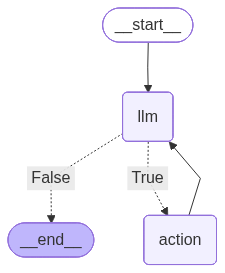

In [ ]:
# -----------------------------------------------------------
# 步骤 6: 可视化流程图（可选）
# -----------------------------------------------------------

from IPython.display import Image, display

# 用图片方式展示流程图
png_data=abot.graph.get_graph().draw_mermaid_png()
Image(png_data)
# abot.graph.get_graph().print_ascii()

In [ ]:
# -----------------------------------------------------------
# 步骤 7: 测试Agent功能
# -----------------------------------------------------------

# 测试1：查询旧金山天气
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'What is the weather in sf?'}, 'id': 'call_d325dba2ca1042cd9fb3b6', 'type': 'tool_call'}
Back to the model!


In [17]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"query": "What is the weather in sf?"}', 'name': 'tavily_search'}, 'id': 'call_d325dba2ca1042cd9fb3b6', 'index': 0, 'type': 'function'}]}, response_metadata={'model_name': 'qwen-turbo', 'finish_reason': 'tool_calls', 'request_id': '37f93c78-a151-45cd-831b-9f5dcc337b70', 'token_usage': {'input_tokens': 1874, 'output_tokens': 27, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 1901}}, id='lc_run--097de0ed-477f-4530-bcae-5dc6905b8497-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'What is the weather in sf?'}, 'id': 'call_d325dba2ca1042cd9fb3b6', 'type': 'tool_call'}]),
  ToolMessage(content='{\'query\': \'What is the weather in sf?\', \'follow_up_questions\': None, \'answer\': None, \'images\': [], \'results\': [{\'title\': \'Weather in San Francisco, CA\', \'url\': 

In [18]:
result['messages'][-1].content

'The current weather in San Francisco, CA is as follows:\n\n- **Temperature**: 18.3°C (64.9°F)\n- **Conditions**: Overcast\n- **Wind**: 21.6 km/h (13.4 mph) from the SSE direction\n- **Humidity**: 78%\n- **Precipitation**: 0.05 mm\n- **Visibility**: 16 km (9 miles)\n\nFor more detailed forecasts and updates, you can check:\n- [Weather in San Francisco, CA](https://www.weatherapi.com/)\n- [San Francisco Weather Forecast for November 13, 2025](https://weathershogun.com/weather/usa/ca/san-francisco/480/november/2025-11-13)\n- [San Francisco Weather in November 2025](https://www.easeweather.com/north-america/united-states/california/city-and-county-of-san-francisco/san-francisco/november)\n- [San Francisco Weather in November 2025: Temperature & Climate](https://en.climate-data.org/north-america/united-states-of-america/california/san-francisco-385/t/november-11/)'

In [ ]:
# 测试2：查询SF和LA天气
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco and Los Angeles', 'search_depth': 'advanced', 'topic': 'general'}, 'id': 'call_b3c41a20cf4641f5ab02ab', 'type': 'tool_call'}
Back to the model!


In [20]:
result['messages'][-1].content

"The current weather in San Francisco and Los Angeles for November 2025 is as follows:\n\n### San Francisco:\n- The weather in San Francisco during November 2025 is expected to be mostly overcast with some rain. \n- Temperatures will range between 12°C and 19°C.\n- There may be light drizzle or moderate rain on several days, with some days being partly cloudy or clear.\n\n### Los Angeles:\n- The weather in Los Angeles during November 2025 is expected to be generally mild, with temperatures ranging from 14°C to 24°C.\n- There might be a few rainy days, but the overall conditions are likely to be mostly sunny or partly cloudy.\n\nIf you're planning a visit, it would be wise to check the specific dates for more detailed forecasts."

In [ ]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.
# 测试3：复杂查询（超级碗+GDP）

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatTongyi(
    model="qwen-turbo",  # 或其他通义千问模型
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),  # 通义千问 API key
    temperature=0, 
)
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'Who won the super bowl in 2024?'}, 'id': 'call_074bf2f862194b758c3abd', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'What is the GDP of Missouri?'}, 'id': 'call_633e2cb805df4bbf990161', 'type': 'tool_call'}
Back to the model!


In [23]:
print(result['messages'][-1].content)

The Kansas City Chiefs won the Super Bowl in 2024. Their headquarters is located in Missouri. 

The GDP of Missouri in 2024 was approximately $356.7 billion (real GDP, adjusted for inflation).
